# Transfer Learning - MobileNetV2

Project:
Explainable AI-Powered Pneumonia Diagnosis & Clinical Decision Support System

Objectives:

- Apply transfer learning
- Improve classification performance
- Compare against baseline CNN
- Reduce overfitting

In [2]:
import os
import numpy as np
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

import matplotlib.pyplot as plt


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATASET_PATH = "/content/drive/MyDrive/archive (6)/chest_xray/chest_xray"

TRAIN_DIR = os.path.join(
    DATASET_PATH,
    "train"
)

TEST_DIR = os.path.join(
    DATASET_PATH,
    "test"
)

In [5]:
IMG_SIZE = 160
BATCH_SIZE = 32

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [7]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

Found 4195 images belonging to 2 classes.


In [8]:
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

Found 1047 images belonging to 2 classes.


In [9]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [10]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
base_model.trainable = False


In [12]:
from tensorflow.keras import Sequential

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation="relu"
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

In [13]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [15]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Pneumonia_CDSS_Project/mobilenetv2_original.keras",
    save_best_only=True,
    monitor="val_loss"
)

In [16]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[
        early_stop,
        checkpoint
    ]

)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 686s 5s/step - accuracy: 0.9192 - loss: 0.2168 - val_accuracy: 0.9542 - val_loss: 0.1455
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 65s 494ms/step - accuracy: 0.9652 - loss: 0.1044 - val_accuracy: 0.9733 - val_loss: 0.0797
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 64s 484ms/step - accuracy: 0.9721 - loss: 0.0833 - val_accuracy: 0.9675 - val_loss: 0.0839
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 81s 480ms/step - accuracy: 0.9738 - loss: 0.0685 - val_accuracy: 0.9465 - val_loss: 0.1221
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 72s 547ms/step - accuracy: 0.9757 - loss: 0.0679 - val_accuracy: 0.9723 - val_loss: 0.0700
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 66s 503ms/step - accuracy: 0.9783 - loss: 0.0621 - val_accuracy: 0.9819 - val_loss: 0.0599
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 83s 509ms/step - accuracy: 0.9800 - loss: 0.0524 - val_accuracy: 0.9771 - val_loss: 0.0689
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 65s 492ms/step - accuracy: 0.9847 - loss: 0.0

In [18]:
from tensorflow.keras.models import load_model

best_model = load_model(
    "/content/drive/MyDrive/Pneumonia_CDSS_Project/mobilenetv2_original.keras"
)

test_loss, test_acc = best_model.evaluate(
    test_generator
)

print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 238s 12s/step - accuracy: 0.7981 - loss: 0.6812
Test Accuracy: 0.7980769276618958


In [19]:
import numpy as np
from sklearn.metrics import classification_report

pred_probs = best_model.predict(
    test_generator
)

preds = (pred_probs > 0.5).astype(int)

print(
    classification_report(
        test_generator.classes,
        preds
    )
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 541ms/step
              precision    recall  f1-score   support

           0       0.98      0.47      0.64       234
           1       0.76      0.99      0.86       390

    accuracy                           0.80       624
   macro avg       0.87      0.73      0.75       624
weighted avg       0.84      0.80      0.78       624



In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    test_generator.classes,
    preds
)

print(cm)

[[110 124]
 [  2 388]]


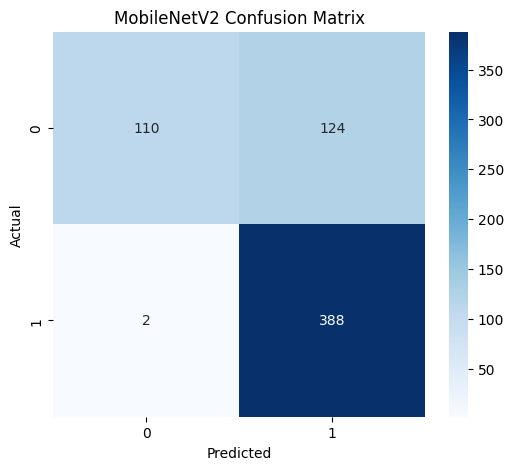

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")

plt.show()

# MobileNetV2 Original Results

## Test Accuracy

79.8%

## Confusion Matrix

[[110 124]
 [  2 388]]

TP = 388
TN = 110
FP = 124
FN = 2

## Key Findings

- The model correctly detected 388 out of 390 pneumonia cases.
- Only 2 pneumonia cases were missed.
- 124 normal images were incorrectly classified as pneumonia.
- The model demonstrates very high sensitivity for pneumonia detection.
- The model is suitable for clinical screening applications where minimizing missed pneumonia cases is critical.

## Conclusion

Although overall accuracy is lower than the augmented model, MobileNetV2 Original achieved superior pneumonia recall and missed only 2 pneumonia cases. Therefore, it was selected as the final deployment model for the Explainable Deep Learning System for Pneumonia Detection.

# ===================================
# Experiment 2
# MobileNetV2 + Data Augmentation
# ===================================

In [22]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

In [23]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 4195 images belonging to 2 classes.
Found 1047 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [24]:
from sklearn.utils.class_weight import compute_class_weight

In [25]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(
    enumerate(class_weights)
)

print(class_weights)

{0: np.float64(1.9349630996309963), 1: np.float64(0.6742205078752812)}


In [26]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
      "/content/drive/MyDrive/Pneumonia_CDSS_Project/mobilenetv2_augmented.keras",
    save_best_only=True,
    monitor="val_loss"
)

In [27]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,

    callbacks=[
        early_stop,
        checkpoint
    ]


)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 109s 762ms/step - accuracy: 0.9364 - loss: 0.1728 - val_accuracy: 0.9389 - val_loss: 0.1641
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 95s 722ms/step - accuracy: 0.9437 - loss: 0.1444 - val_accuracy: 0.9522 - val_loss: 0.1095
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 93s 705ms/step - accuracy: 0.9497 - loss: 0.1286 - val_accuracy: 0.9599 - val_loss: 0.0958
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 94s 716ms/step - accuracy: 0.9461 - loss: 0.1384 - val_accuracy: 0.9446 - val_loss: 0.1472
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 93s 709ms/step - accuracy: 0.9523 - loss: 0.1203 - val_accuracy: 0.9494 - val_loss: 0.1584
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 97s 736ms/step - accuracy: 0.9502 - loss: 0.1222 - val_accuracy: 0.9561 - val_loss: 0.1165


In [28]:
from tensorflow.keras.models import load_model

best_model = load_model(
      "/content/drive/MyDrive/Pneumonia_CDSS_Project/mobilenetv2_augmented.keras"
)

In [29]:
test_loss, test_acc = best_model.evaluate(
    test_generator
)

print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 512ms/step - accuracy: 0.8926 - loss: 0.3055
Test Accuracy: 0.8926281929016113


In [30]:
pred_probs = best_model.predict(test_generator)

preds = (pred_probs > 0.5).astype(int)

from sklearn.metrics import classification_report

print(
    classification_report(
        test_generator.classes,
        preds
    )
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 578ms/step
              precision    recall  f1-score   support

           0       0.81      0.93      0.87       234
           1       0.95      0.87      0.91       390

    accuracy                           0.89       624
   macro avg       0.88      0.90      0.89       624
weighted avg       0.90      0.89      0.89       624



In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    test_generator.classes,
    preds
)

print(cm)

[[217  17]
 [ 50 340]]


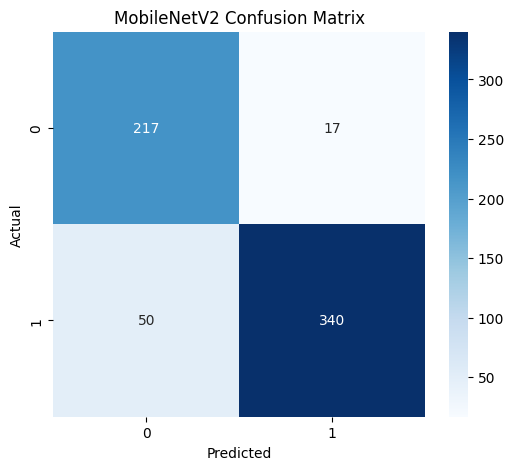

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")

plt.show()

# MobileNetV2 with Data Augmentation Results

## Test Accuracy

89.3%

## Confusion Matrix

[[217, 17],
 [ 50, 340]]

### Key Findings

- Achieved the highest overall accuracy.
- Significantly reduced false positive predictions.
- Correctly identified 217 normal cases.
- Missed 50 pneumonia cases.
- Improved class balance and specificity.

### Conclusion

Data augmentation improved overall classification accuracy and reduced false alarms. However, the model missed 50 pneumonia cases, making it less suitable for clinical screening despite higher accuracy.

In [33]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "MobileNetV2",
        "MobileNetV2 + Augmentation"
    ],
    "Accuracy (%)": [62.5, 79.8, 89.3],
    "Pneumonia Recall": [1.00, 0.99, 0.87],
    "False Negatives": [0, 2, 50]
})

comparison

,Model,Accuracy (%),Pneumonia Recall,False Negatives
0,Baseline CNN,62.5,1.00,0
1,MobileNetV2,79.8,0.99,2
2,MobileNetV2 + Augmentation,89.3,0.87,50


## Model Comparison

The baseline CNN achieved 62.5% test accuracy but showed a strong bias toward the pneumonia class, incorrectly classifying most normal chest X-rays as pneumonia cases.

The original MobileNetV2 model improved performance significantly, achieving 79.8% test accuracy while maintaining a pneumonia recall of approximately 99%. It missed only 2 pneumonia cases, making it highly suitable for medical screening applications where minimizing missed diagnoses is critical.

MobileNetV2 with data augmentation achieved the highest overall accuracy of 89.3% and substantially reduced false positive predictions. However, it missed 50 pneumonia cases, resulting in a lower pneumonia recall compared to the original MobileNetV2 model.

Considering the clinical objective of minimizing false negatives and ensuring reliable pneumonia detection, the original MobileNetV2 model was selected as the final deployment model despite its lower overall accuracy. Its ability to correctly identify nearly all pneumonia cases makes it more appropriate for a clinical decision support system.